# Generalized IRFs and failure awareness

## 1. Scientific question

How sensitive are lifetime estimates to IRF shape assumptions, and when can an approximate leading-edge IRF proxy be misleading even when it is numerically well formed?

This notebook composes the committed Issue-#8 library APIs. It does not change the frozen Week-8 A–F protocol. Synthetic truth is used only in controlled simulations; the imported CSV example is explicitly a synthetic experimental-style stand-in, not an independently measured IRF.

Run all cells from a fresh kernel with the project installed in editable mode. The fixed demonstration settings are in `configs/issue8_irf_workflow.json`; this is the audited Stage-6 fixture, not a broad robustness or coverage study.

In [1]:
import json
from dataclasses import asdict
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from tcspc_toolkit.config import FeatureConfig
from tcspc_toolkit.experimental import fit_experimental_reconvolution
from tcspc_toolkit.irf import (
    IRFProfile, IRFSourceKind,
    generate_gaussian_irf_profile, generate_emg_irf_profile,
)
from tcspc_toolkit.irf_preparation import (
    irf_profile_from_sampled_irf, prepare_irf,
)
from tcspc_toolkit.irf_estimation import estimate_irf_from_leading_edge
from tcspc_toolkit.irf_evaluation import (
    IRFShapeMismatchConfig, LeadingEdgeFailureConfig,
    generate_irf_shape_mismatch_dataset, evaluate_irf_shape_classical,
    summarize_irf_shape_classical, evaluate_irf_shape_conditional_uncertainty,
    evaluate_gaussian_trained_irf_transfer, evaluate_leading_edge_failure_regimes,
)
from tcspc_toolkit.measurement_io import (
    load_sampled_irf_csv, load_tcspc_measurement_csv,
)
from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.simulation import (
    build_expected_counts_from_irf, sample_photon_counts,
)

pd.set_option('display.max_columns', 16)
pd.set_option('display.precision', 6)
pd.set_option('display.max_colwidth', None)
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True})

In [2]:
repo_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / 'configs' / 'issue8_irf_workflow.json').is_file()
)
config_path = repo_root / 'configs' / 'issue8_irf_workflow.json'
manifest = json.loads(config_path.read_text(encoding='utf-8'))
shape_time = np.arange(**manifest['shape_grid_ns'])
leading_time = np.arange(**manifest['leading_grid_ns'])
shape_config = IRFShapeMismatchConfig(
    time_ns=shape_time, **manifest['shape_mismatch'],
)
leading_options = dict(manifest['leading_edge'])
for key in ('background_window_ns', 'rising_edge_window_ns', 'temporal_shift_bounds_ns'):
    leading_options[key] = tuple(leading_options[key])
leading_config = LeadingEdgeFailureConfig(time_ns=leading_time, **leading_options)
feature_config = FeatureConfig(**manifest['feature_config'])

display(pd.Series(
    {name: version(name) for name in ('numpy', 'scipy', 'pandas', 'scikit-learn')},
    name='execution versions',
).to_frame())
display(pd.Series(manifest['ml'], name='fixed data roles').to_frame())
print('Manifest:', config_path.relative_to(repo_root))
print('Seeds:', shape_config.random_seed, leading_config.random_seed,
      manifest['conditional_uncertainty']['random_seed'],
      manifest['forward_demo']['random_seed'])

,execution versions
numpy,2.5.1
scipy,1.18.0
pandas,3.0.3
scikit-learn,1.9.0


,fixed data roles
random_state,42
development_role,120 Gaussian histograms; 30 per lifetime; all representation/model fitting
external_role,8 Gaussian-control and 8 EMG histograms; 2 new Poisson realizations per lifetime in each population; evaluation only
calibration_role,"none; RF tree spread is a disagreement score, not a calibrated interval"


Manifest: configs\issue8_irf_workflow.json
Seeds: 8601 8603 1119 8616


## 2. Generalized IRF architecture

```text
Gaussian / EMG generation ───────────────┐
SampledIRF → explicit source adapter ───┼→ IRFProfile → prepare_irf → PreparedIRF
explicit leading-edge estimate ─────────┘                              ↓
                                               array-based convolution / reconvolution
```

Source/origin, sampled source values, preparation history, and a forward-model kernel are different things. An `IRFProfile` validates and preserves its supplied values; it does not normalize, smooth, resample, or infer zero time. Nonuniform source grids are allowed.

`SampledIRF` remains the Issue-#6 import/measurement carrier with original values, metadata, and provenance. Its adapter labels the source `imported_sampled`, which does not establish that the trace is an independent physical measurement. `PreparedIRF` holds a normalized derived kernel on a uniform target grid. Preparation diagnostics record transformations without rewriting source provenance.

## 3. Gaussian versus EMG

The EMG convolves a Gaussian component with a causal exponential tail. Its `gaussian_centre_ns` and `gaussian_fwhm_ns` describe the Gaussian component, **not** the final EMG peak and full FWHM. Positive tail time gives positive skew; exactly zero tail delegates to the existing Gaussian generator.

These examples share component parameters, so they deliberately differ in full width and peak. The later shape-mismatch study instead matches the *sampled full FWHM and peak* before comparing estimators. Source amplitudes are preserved; area normalization is explicit preparation.

,profile,source_kind,component_centre_ns,component_fwhm_ns,sampled_peak_ns,full_sampled_fwhm_ns,source_area,prepared_area
0,Gaussian,synthetic_gaussian,2.0,0.4,2.00,0.400000,0.425787,1.0
1,EMG,synthetic_emg,2.0,0.4,2.18,0.652189,0.425787,1.0


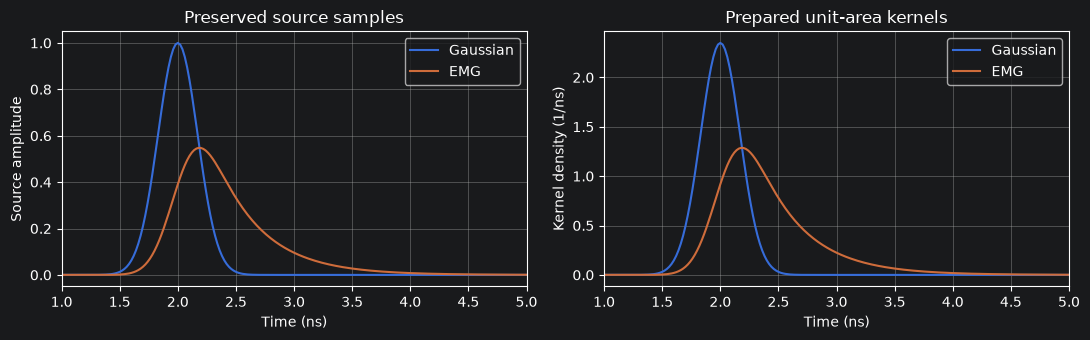

In [3]:
profile_settings = manifest['profile_demo']
gaussian_profile = generate_gaussian_irf_profile(
    leading_time,
    gaussian_centre_ns=profile_settings['gaussian_centre_ns'],
    gaussian_fwhm_ns=profile_settings['gaussian_fwhm_ns'],
    amplitude=profile_settings['amplitude'],
)
emg_profile = generate_emg_irf_profile(leading_time, **profile_settings)
demo_prepared = {
    'Gaussian': prepare_irf(gaussian_profile, leading_time),
    'EMG': prepare_irf(emg_profile, leading_time),
}
display(pd.DataFrame([
    {
        'profile': label, 'source_kind': prepared.source.source_kind.value,
        'component_centre_ns': prepared.source.source_parameters['gaussian_centre_ns'],
        'component_fwhm_ns': prepared.source.source_parameters['gaussian_fwhm_ns'],
        'sampled_peak_ns': prepared.time_ns[np.argmax(prepared.kernel)],
        'full_sampled_fwhm_ns': prepared.diagnostics.target_fwhm_ns,
        'source_area': prepared.diagnostics.source_area,
        'prepared_area': prepared.diagnostics.target_area_after_normalization,
    }
    for label, prepared in demo_prepared.items()
]))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for label, prepared in demo_prepared.items():
    axes[0].plot(prepared.source.time_ns, prepared.source.values, label=label)
    axes[1].plot(prepared.time_ns, prepared.kernel, label=label)
for ax, title in zip(axes, ('Preserved source samples', 'Prepared unit-area kernels')):
    ax.set(xlim=(1, 5), xlabel='Time (ns)', title=title)
    ax.legend()
axes[0].set_ylabel('Source amplitude')
axes[1].set_ylabel('Kernel density (1/ns)')
fig.tight_layout()
plt.show()

## 4. Explicit preparation: normalization, registration, resampling

Positive `registration_offset_ns` moves the source later. Registration is a caller-supplied coordinate correction; resampling changes the sampling grid. Neither is the residual temporal shift fitted by reconvolution. `resampling='none'` never silently interpolates; `'linear'` uses one deterministic interpolation with zero extrapolation.

The committed CSV trace below is synthetic. Import preserves it exactly. We explicitly adapt, register by +0.1 ns, and resample it for illustration; no measurement or source is altered.

In [4]:
experimental_settings = manifest['experimental_demo']
sampled_irf = load_sampled_irf_csv(
    repo_root / experimental_settings['irf_csv'],
    time_unit=experimental_settings['irf_time_unit'],
    time_column=experimental_settings['irf_time_column'],
)
imported_profile = irf_profile_from_sampled_irf(sampled_irf)
np.testing.assert_array_equal(imported_profile.time_ns, sampled_irf.time_ns)
np.testing.assert_array_equal(imported_profile.values, sampled_irf.values)
original_imported_values = sampled_irf.values.copy()
prep_settings = manifest['preparation_demo']
import_target = np.arange(
    sampled_irf.time_ns[0],
    sampled_irf.time_ns[-1] + prep_settings['target_bin_width_ns'] / 2,
    prep_settings['target_bin_width_ns'],
)
registered_import = prepare_irf(
    imported_profile, import_target, resampling='linear',
    registration_offset_ns=prep_settings['registration_offset_ns'],
)
display(pd.Series(asdict(registered_import.diagnostics), name='explicit preparation').to_frame())
assert imported_profile.source_kind == IRFSourceKind.IMPORTED_SAMPLED
np.testing.assert_array_equal(sampled_irf.values, original_imported_values)

,explicit preparation
source_area,6.386222
retained_source_area,6.386222
support_retained_fraction,1.0
support_loss_fraction,0.0
target_area_before_normalization,6.386392
target_area_after_normalization,1.0
normalization_factor,0.156583
target_minus_retained_area,0.00017
source_spacing_min_ns,0.25
source_spacing_max_ns,0.25


Geometric support loss measures only the available, registered piecewise-linear source outside the target acquisition window. It cannot account for unobserved physical tails. The retained-source integral includes partial interpolation intervals exactly.

Target-grid quadrature is a separate quantity: the coarse grid below contains the entire source window, yet samples the narrow triangle poorly. No support is geometrically lost, but its pre-normalization trapezoidal area changes from 0.35 to 0.25. Normalization does not repair insufficient temporal resolution. Support-loss acceptability is application dependent; no universal warning/failure threshold is imposed.

In [5]:
support_profile = IRFProfile(
    time_ns=prep_settings['support_source_time_ns'],
    values=prep_settings['support_source_values'],
    source_kind=IRFSourceKind.IMPORTED_SAMPLED,
    metadata={'description': 'constructed piecewise-linear sampling illustration'},
)
support_examples = {
    'whole window, coarse grid': prepare_irf(
        support_profile, prep_settings['support_target_time_ns'], resampling='linear',
    ),
    'clipped window': prepare_irf(
        support_profile, prep_settings['clipped_target_time_ns'], resampling='linear',
    ),
}
support_columns = [
    'source_area', 'retained_source_area', 'support_loss_fraction',
    'target_area_before_normalization', 'target_area_after_normalization',
    'target_minus_retained_area', 'normalization_factor',
]
support_table = pd.DataFrame({
    label: asdict(prepared.diagnostics) for label, prepared in support_examples.items()
}).T[support_columns]
display(support_table)
whole = support_examples['whole window, coarse grid'].diagnostics
assert whole.support_loss_fraction == 0.0
np.testing.assert_allclose(
    [whole.source_area, whole.target_area_before_normalization], [0.35, 0.25],
)
assert support_examples['clipped window'].diagnostics.support_loss_fraction > 0

,source_area,retained_source_area,support_loss_fraction,target_area_before_normalization,target_area_after_normalization,target_minus_retained_area,normalization_factor
"whole window, coarse grid",0.35,0.35,0.0,0.25,1.0,-0.1,4.0
clipped window,0.35,0.245833,0.297619,0.229167,1.0,-0.016667,4.363636


## 5. One generic forward model

Both kernels use the same library convolution path. `build_expected_counts_from_irf` returns deterministic expected counts; `sample_photon_counts` is a separate Poisson operation. The signal budget is the expected detected signal **within the finite acquisition window**, while background is expected counts per bin. These are synthetic histograms, not experimental truth labels.

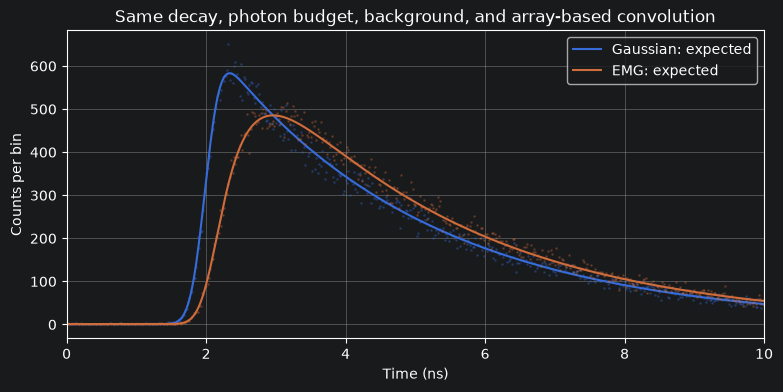

In [6]:
forward = manifest['forward_demo']
ideal_decay = monoexponential_decay(
    time=leading_time, amplitude=1.0, lifetime=forward['lifetime_ns'],
)
rng = np.random.default_rng(forward['random_seed'])
expected_by_source = {}
observed_by_source = {}
for label, prepared in demo_prepared.items():
    expected = build_expected_counts_from_irf(
        ideal_decay, prepared,
        signal_photon_count=forward['signal_photon_count'],
        background_per_bin=forward['background_per_bin'],
    )
    expected_by_source[label] = expected
    observed_by_source[label] = sample_photon_counts(expected, rng)
    np.testing.assert_allclose(
        np.sum(expected - forward['background_per_bin']),
        forward['signal_photon_count'], rtol=1e-12,
    )
fig, ax = plt.subplots()
for label, expected in expected_by_source.items():
    line, = ax.plot(leading_time, expected, label=f'{label}: expected')
    ax.plot(leading_time, observed_by_source[label], '.', ms=2,
            color=line.get_color(), alpha=0.25)
ax.set(xlim=(0, 10), xlabel='Time (ns)', ylabel='Counts per bin',
       title='Same decay, photon budget, background, and array-based convolution')
ax.legend()
plt.show()

## 6. Experimental reconvolution: explicit kernel precedence

`fit_experimental_reconvolution(..., prepared_irf=...)` uses the supplied kernel even when the measurement has an attached `SampledIRF`. It checks target-grid compatibility and never prepares, resamples, or registers an IRF automatically. Without the explicit argument, the legacy Issue-#6 path normalizes a derived copy of the attached trace, unchanged.

We reuse the synthetic CSV stand-in from Notebook 15. Units and raw-count semantics are explicit; the measurement receives no ground truth. Preparing the imported source on the same grid reproduces the attached-IRF path below. Choosing a different prepared kernel would deliberately override it, not trigger a comparison or automatic selection.

In [7]:
measurement = load_tcspc_measurement_csv(
    repo_root / experimental_settings['measurement_csv'],
    time_unit=experimental_settings['measurement_time_unit'],
    time_column=experimental_settings['measurement_time_column'],
    data_kind='raw_counts', irf=sampled_irf,
    sample_id='notebook-16-synthetic-import-demo',
)
imported_prepared = prepare_irf(imported_profile, measurement.time_ns)
fit_options = {
    'temporal_shift_bounds_ns': tuple(experimental_settings['temporal_shift_bounds_ns']),
    'background_fraction': experimental_settings['background_fraction'],
}
legacy_fit = fit_experimental_reconvolution(measurement, **fit_options)
explicit_fit = fit_experimental_reconvolution(
    measurement, prepared_irf=imported_prepared, **fit_options,
)
display(pd.DataFrame([
    {'path': label, 'estimated_lifetime_ns': fit.fitted_lifetime_ns,
     'valid_fit': fit.valid_fit, 'poisson_deviance': fit.poisson_deviance}
    for label, fit in [('attached SampledIRF', legacy_fit), ('explicit PreparedIRF', explicit_fit)]
]))
np.testing.assert_allclose(legacy_fit.fitted_lifetime_ns, explicit_fit.fitted_lifetime_ns)
np.testing.assert_array_equal(sampled_irf.values, original_imported_values)

,path,estimated_lifetime_ns,valid_fit,poisson_deviance
0,attached SampledIRF,3.002089,True,76.642843
1,explicit PreparedIRF,3.002089,True,76.642843


## 7. Explicit leading-edge proxy: favorable condition first

For mono-exponential fluorescence, $S'(t) = A h(t) - S(t)/\tau$. Consequently $h(t) \ne S'(t)$ in general. This approximation does **not** estimate the missing $S/\tau$ term or recover a measured/true IRF.

The favorable synthetic case has an 8 ns lifetime, Gaussian IRF full FWHM 0.4 ns and peak 2 ns, 2,000,000 signal photons, and background 1 count/bin. Sampling is 0.02 ns. Background [0, 1) ns and candidate edge [1.2, 4) ns are explicitly selected; a 17-bin, order-3 Savitzky–Golay filter provides smoothing and a count/ns derivative (`mode='interp'`). Negative background-subtracted fluctuations survive smoothing; only negative derivative contributions to the constructed proxy are clipped and diagnosed.

The library study retains raw realizations, proxy diagnostics, known synthetic IRFs, and downstream fits. We also show the caller-controlled estimator → preparation → fitter steps explicitly. No fitter invokes this estimator as a fallback.

,proxy diagnostics
status,proxy_constructed
failure_reason,None
flags,"(negative_derivative_clipped_for_proxy,)"
requested_background_window_ns,"(0.0, 1.0)"
background_bin_range,"(0, 50)"
requested_rising_edge_window_ns,"(1.2, 4.0)"
rising_edge_bin_range,"(60, 200)"
selected_rising_segment_bin_range,"(60, 120)"
background_estimate_counts_per_bin,1.06
smoothing_window_bins,17


,proxy_peak_ns,proxy_fwhm_ns,normalized_L1_error,peak_error_ns,fwhm_error_ns,true_IRF_fit_ns,proxy_IRF_fit_ns
0,1.96,0.383277,0.091641,-0.04,-0.016723,7.995458,8.008096


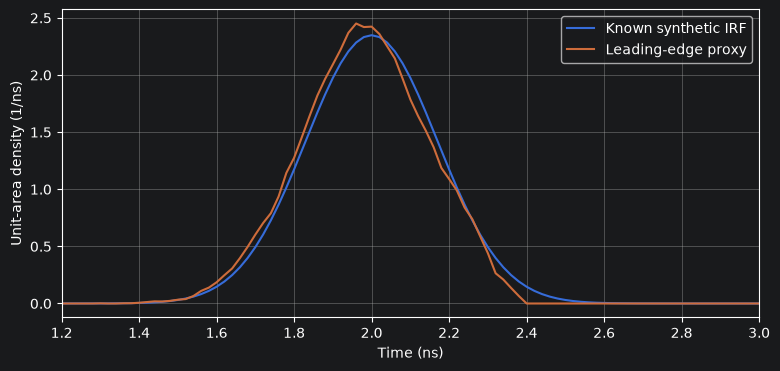

In [8]:
leading_evaluation = evaluate_leading_edge_failure_regimes(leading_config)
leading_cases = {case.regime: case for case in leading_evaluation.cases}
favorable = leading_cases['favorable']
proxy_result = estimate_irf_from_leading_edge(
    favorable.measurement,
    background_window_ns=leading_config.background_window_ns,
    rising_edge_window_ns=leading_config.rising_edge_window_ns,
    smoothing_window_bins=leading_config.smoothing_window_bins,
    polynomial_order=leading_config.polynomial_order,
)
assert proxy_result.profile is not None
assert proxy_result.profile.source_kind == IRFSourceKind.LEADING_EDGE_ESTIMATE
proxy_prepared = prepare_irf(proxy_result.profile, favorable.measurement.time_ns)
proxy_fit = fit_experimental_reconvolution(
    favorable.measurement, prepared_irf=proxy_prepared,
    temporal_shift_bounds_ns=leading_config.temporal_shift_bounds_ns,
)
np.testing.assert_array_equal(proxy_result.profile.values, favorable.proxy.profile.values)
display(pd.Series(asdict(proxy_result.diagnostics), name='proxy diagnostics').to_frame())
display(pd.DataFrame([{
    'proxy_peak_ns': proxy_result.diagnostics.proxy_peak_time_ns,
    'proxy_fwhm_ns': proxy_result.diagnostics.proxy_fwhm_ns,
    'normalized_L1_error': favorable.proxy_l1_shape_error,
    'peak_error_ns': favorable.proxy_peak_time_error_ns,
    'fwhm_error_ns': favorable.proxy_fwhm_error_ns,
    'true_IRF_fit_ns': favorable.true_irf_fit.fitted_lifetime_ns,
    'proxy_IRF_fit_ns': proxy_fit.fitted_lifetime_ns,
}]))
fig, ax = plt.subplots()
ax.plot(leading_time, favorable.true_prepared_irf.kernel, label='Known synthetic IRF')
ax.plot(leading_time, proxy_prepared.kernel, label='Leading-edge proxy')
ax.set(xlim=(1.2, 3.0), xlabel='Time (ns)', ylabel='Unit-area density (1/ns)')
ax.legend()
plt.show()

## 8. Controlled leading-edge failure regimes

Each adverse condition changes its stated factor relative to the favorable baseline wherever physically possible. The EMG control is matched to baseline sampled peak/full FWHM. The finite-rise signal is the committed, local control $d(u) \propto e^{-u/\tau_d}-e^{-u/\tau_r}$ for $u\geq0$, with decay 8 ns and rise 0.5 ns; it is not a general public decay model.

Construction status, factual flags, actual synthetic shape error, and downstream lifetime estimates answer different questions. The normalized L1 error is the trapezoidal integral of the absolute difference between unit-area proxy and generating IRF. A finite, nonnegative proxy is not a physical-validity certificate.

Bi-exponential (0.4/8 ns; short-component amplitude fraction 0.9) and finite-rise rows have **no unique mono-exponential truth**: their scalar reconvolution outputs are estimates under a misspecified mono-exponential decay model, not lifetime errors against an invented truth.

Both translated controls use +2.2 ns IRF registration. The correct window shifts to [3.4, 6.2) ns; the wrong window stays [1.2, 4) ns. They use **independent Poisson realizations, not identical-count window ablation**. Translation also changes the remaining finite acquisition window; the expected detected photon budget is still fixed. No automatic realignment occurs.

,regime,proxy_status,proxy_l1_shape_error,proxy_peak_time_error_ns,proxy_fwhm_error_ns,monoexponential_reference_lifetime_ns,true_irf_lifetime_estimate_ns,proxy_irf_lifetime_estimate_ns
0,favorable,proxy_constructed,0.091641,-0.04,-0.016723,8.00,7.995458,8.008096
1,low_photon_count,proxy_constructed,1.009749,0.02,NaN,8.00,7.481860,7.157688
2,high_background,proxy_constructed,0.120736,0.02,-0.044200,8.00,8.009286,8.033546
3,comparable_lifetime,proxy_constructed,0.496261,-0.06,-0.066444,0.40,0.400538,0.428982
4,very_short_lifetime,proxy_constructed,0.912417,-0.12,-0.111478,0.08,0.079596,0.152618
5,bi_exponential,proxy_constructed,0.449348,-0.04,-0.059195,NaN,1.498194,1.532768
6,translated_irf_correct_window,proxy_constructed,0.103228,0.00,-0.031509,8.00,8.021581,8.027358
7,misregistered_analysis_window,failed,NaN,NaN,NaN,8.00,7.998500,NaN
8,strongly_asymmetric_irf,proxy_constructed,0.210944,0.04,NaN,8.00,7.988998,8.190455
9,finite_physical_rise,proxy_constructed,1.031587,0.20,0.286877,NaN,8.659080,8.246961


,regime,proxy_failure_reason,proxy_flags,estimated_background_fraction_of_rising_counts,negative_derivative_fraction
0,favorable,NaN,"(negative_derivative_clipped_for_proxy,)",0.000301,1.204325e-04
1,low_photon_count,NaN,"(negative_derivative_clipped_for_proxy, proxy_fwhm_unavailable)",0.219092,3.174343e-01
2,high_background,NaN,"(background_at_least_half_observed_rising_counts, negative_derivative_clipped_for_proxy)",0.585638,1.280331e-02
3,comparable_lifetime,NaN,"(negative_derivative_clipped_for_proxy,)",0.000078,9.038494e-06
4,very_short_lifetime,NaN,"(negative_derivative_clipped_for_proxy,)",0.000064,4.824085e-07
5,bi_exponential,NaN,"(negative_derivative_clipped_for_proxy,)",0.000179,6.267850e-06
6,translated_irf_correct_window,NaN,"(negative_derivative_clipped_for_proxy,)",0.000239,7.673897e-05
7,misregistered_analysis_window,smoothed_peak_at_rising_window_boundary,(),0.048679,NaN
8,strongly_asymmetric_irf,NaN,"(negative_derivative_clipped_for_proxy, proxy_fwhm_unavailable)",0.000489,5.010343e-03
9,finite_physical_rise,NaN,"(negative_derivative_clipped_for_proxy,)",0.000454,1.981940e-03


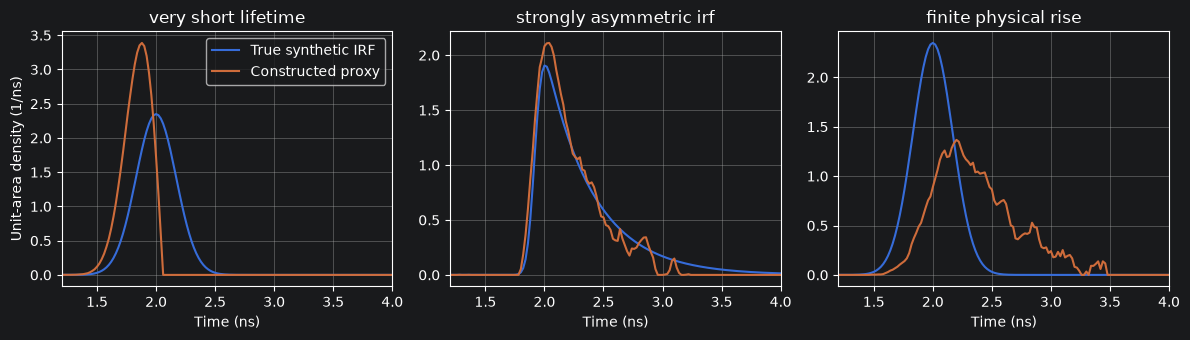

In [9]:
regime_columns = [
    'regime', 'proxy_status', 'proxy_l1_shape_error',
    'proxy_peak_time_error_ns', 'proxy_fwhm_error_ns',
    'monoexponential_reference_lifetime_ns',
    'true_irf_lifetime_estimate_ns', 'proxy_irf_lifetime_estimate_ns',
]
display(leading_evaluation.per_case[regime_columns])
display(leading_evaluation.per_case[[
    'regime', 'proxy_failure_reason', 'proxy_flags',
    'estimated_background_fraction_of_rising_counts', 'negative_derivative_fraction',
]])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, regime in zip(axes, (
    'very_short_lifetime', 'strongly_asymmetric_irf', 'finite_physical_rise',
)):
    case = leading_cases[regime]
    ax.plot(leading_time, case.true_prepared_irf.kernel, label='True synthetic IRF')
    if case.proxy.profile is not None:
        ax.plot(leading_time, case.proxy.profile.values, label='Constructed proxy')
    ax.set(xlim=(1.2, 4), xlabel='Time (ns)', title=regime.replace('_', ' '))
axes[0].set_ylabel('Unit-area density (1/ns)')
axes[0].legend()
fig.tight_layout()
plt.show()

The wrong-window case fails construction. Low photons and strong asymmetry lack an identifiable proxy FWHM; high background triggers a background-fraction flag. Negative derivative clipping is explicitly recorded even for the favorable case.

Comparable/very-short lifetimes and finite physical rise can still produce numerically valid, physically poor proxies. The high-background realization here remains fairly accurate despite its flag. Flags are not guaranteed mismatch detectors, and this one-realization-per-regime demonstration is not a failure-probability estimate.

## 9. IRF shape-family mismatch: paired same-count fits

The noiseless EMG has Gaussian-component centre 1.5 ns, component FWHM 0.35 ns, and exponential tail 0.18 ns. The library constructs a Gaussian using only the IRF's sampled principal peak and full FWHM, never fluorescence outcomes. Matching those two quantities does not make the shapes equivalent.

For each of eight EMG histograms, the **same counts** are fit twice: matched EMG versus matched-peak/FWHM Gaussian. Lifetime, expected signal photons (200,000), background (1/bin), acquisition grid ([0,12) ns at 0.02 ns), Poisson objective, shift bounds (±0.2 ns), and initialization policy are paired. The Gaussian control has matched nuisance conditions but independent Poisson counts.

All fitting, residuals, and metrics below come from the committed evaluation module. This experiment is independent of frozen Week-8 A–F.

,assumed_irf,n_histograms,n_valid_fits,n_boundary_hits,mae_ns,bias_ns,mean_poisson_deviance
0,matched_emg,8,8,0,0.005909,0.000906,591.609359
1,gaussian_assumed,8,8,0,0.032795,0.032795,709.710133
2,gaussian_control,8,8,0,0.003490,0.002798,615.431037


,kernel,peak_ns,full_fwhm_ns
0,true EMG,1.62,0.451455
1,comparison Gaussian,1.62,0.451455


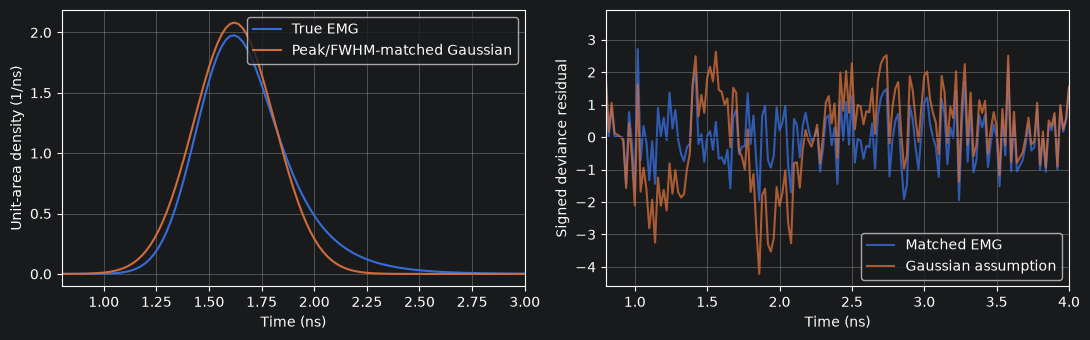

In [10]:
shape_dataset = generate_irf_shape_mismatch_dataset(shape_config)
classical = evaluate_irf_shape_classical(shape_dataset)
classical_summary = summarize_irf_shape_classical(classical)
display(classical_summary)
emg_kernel = shape_dataset.true_emg_irfs[0]
comparison_kernel = shape_dataset.comparison_gaussian_irfs[0]
match_table = pd.DataFrame([
    {'kernel': label, 'peak_ns': prepared.time_ns[np.argmax(prepared.kernel)],
     'full_fwhm_ns': prepared.diagnostics.target_fwhm_ns}
    for label, prepared in [('true EMG', emg_kernel), ('comparison Gaussian', comparison_kernel)]
])
display(match_table)
np.testing.assert_allclose(match_table['peak_ns'].iloc[0], match_table['peak_ns'].iloc[1], atol=1e-12)
np.testing.assert_allclose(match_table['full_fwhm_ns'].iloc[0], match_table['full_fwhm_ns'].iloc[1], atol=1e-9)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(shape_time, emg_kernel.kernel, label='True EMG')
axes[0].plot(shape_time, comparison_kernel.kernel, label='Peak/FWHM-matched Gaussian')
axes[0].set(xlim=(0.8, 3), xlabel='Time (ns)', ylabel='Unit-area density (1/ns)')
pair = classical.pairs[0]
axes[1].plot(shape_time, pair.matched_emg_residuals, label='Matched EMG', alpha=0.8)
axes[1].plot(shape_time, pair.gaussian_assumed_residuals, label='Gaussian assumption', alpha=0.8)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set(xlim=(0.8, 4), xlabel='Time (ns)', ylabel='Signed deviance residual')
for ax in axes:
    ax.legend()
fig.tight_layout()
plt.show()

The audited fixed-seed results are approximately:

| Data / assumed IRF | MAE (ns) | Bias (ns) | Mean Poisson deviance |
|---|---:|---:|---:|
| EMG / matched EMG | 0.0059 | +0.0009 | 591.6 |
| Same EMG counts / Gaussian | 0.0328 | +0.0328 | 709.7 |
| Gaussian control / Gaussian | 0.0035 | +0.0028 | 615.4 |

All 24 fits are valid with no reported boundary parameters in this fixture. The mean deviance and residual profiles show a mismatch effect here; neither scalar deviance nor residual summaries are universal physics-validity tests. Matched deviance need not beat misspecified deviance for every possible noisy realization.

## 10. Conditional uncertainty under an incorrect IRF

The selected histogram has true lifetime 1 ns. Local Poisson/Fisher covariance and parametric Poisson bootstrap hold **each assumed IRF fixed**; neither propagates IRF-shape uncertainty.

For the Gaussian assumption, the audited estimate is about 1.0287 ns with local standard deviation 0.00269 ns. The three-resample bootstrap percentile endpoints are about 1.0255–1.0309 ns. These **three resamples demonstrate the interface only**. The requested nominal level is not verified calibration, and this is not a coverage study. The point is conditional statistical uncertainty can be small around a biased estimate.

In [11]:
conditional = evaluate_irf_shape_conditional_uncertainty(
    shape_dataset, classical, **manifest['conditional_uncertainty'],
)
display(conditional.per_fit)
print('Bootstrap resamples per assumed IRF:',
      manifest['conditional_uncertainty']['n_bootstrap_resamples'])
print('Fixed-IRF statistical uncertainty only; no IRF-shape uncertainty or calibration claim.')

,pair_id,assumed_irf,true_lifetime_ns,estimated_lifetime_ns,fit_valid,uncertainty_scope,covariance_valid,local_lifetime_std_ns,local_failure_reason,bootstrap_valid,bootstrap_lifetime_std_ns,bootstrap_lower_ns,bootstrap_upper_ns,bootstrap_n_successful_fits,bootstrap_failure_reason
0,0,matched_emg,1.0,1.004166,True,conditional_on_assumed_fixed_irf,True,0.002646,None,True,0.004452,0.999421,1.006630,3,None
1,0,gaussian_assumed,1.0,1.028703,True,conditional_on_assumed_fixed_irf,True,0.002688,None,True,0.003245,1.025463,1.030904,3,None


Bootstrap resamples per assumed IRF: 3
Fixed-IRF statistical uncertainty only; no IRF-shape uncertainty or calibration claim.


## 11. Gaussian-trained ML transfer

The development population contains 120 Gaussian histograms: 30 at each lifetime in {1, 2, 3, 4} ns. Each external population contains eight independent histograms: two at each of the **same discrete lifetime values**. Thus the external lifetime support is identical to, not outside, the development support; only Poisson realizations and the EMG shape family differ.

Ridge, Random Forest, and HistGradientBoosting use the same fixed histogram-feature extraction. Representation and estimator fitting use Gaussian development data only. Lifetime labels, IRF/source metadata, and target-derived quantities are not model features. External populations enter prediction/evaluation only: no tuning, refitting, or calibration. The feature list and distributions are displayed for auditability.

RF tree spread is an ensemble disagreement score, not a nominal prediction interval, conformal interval, or classical model-conditional parameter uncertainty.

,population,n_histograms,raw_histogram_shape,finite_histograms,lifetime_ns_to_count
0,gaussian_development,120,"(120, 600)",True,"{1.0: 30, 2.0: 30, 3.0: 30, 4.0: 30}"
1,gaussian_control,8,"(8, 600)",True,"{1.0: 2, 2.0: 2, 3.0: 2, 4.0: 2}"
2,emg_external,8,"(8, 600)",True,"{1.0: 2, 2.0: 2, 3.0: 2, 4.0: 2}"


Model feature columns: ('total_counts', 'peak_height', 'peak_time_ns', 'mean_arrival_time_ns', 'arrival_time_variance_ns2', 'arrival_time_skewness', 't10_ns', 't25_ns', 't50_ns', 't75_ns', 't90_ns', 'half_decay_time_ns', 'tail_log_slope_per_ns', 'integrated_tail_fraction', 'early_late_count_ratio')


,population,model,n_histograms,mae_ns,rmse_ns,bias_ns,mean_relative_error,mean_rf_tree_spread_ns
0,gaussian_control,ridge,8,0.022274,0.030956,5.658503e-03,0.008249,NaN
1,gaussian_control,hist_gradient_boosting,8,0.000027,0.000030,-5.450640e-13,0.000015,NaN
2,gaussian_control,random_forest,8,0.000000,0.000000,0.000000e+00,0.000000,0.000000
3,emg_external,ridge,8,0.204581,0.210171,2.045806e-01,0.095914,NaN
4,emg_external,hist_gradient_boosting,8,0.000027,0.000030,-5.450640e-13,0.000015,NaN
5,emg_external,random_forest,8,0.013750,0.027613,1.375000e-02,0.004583,0.056929


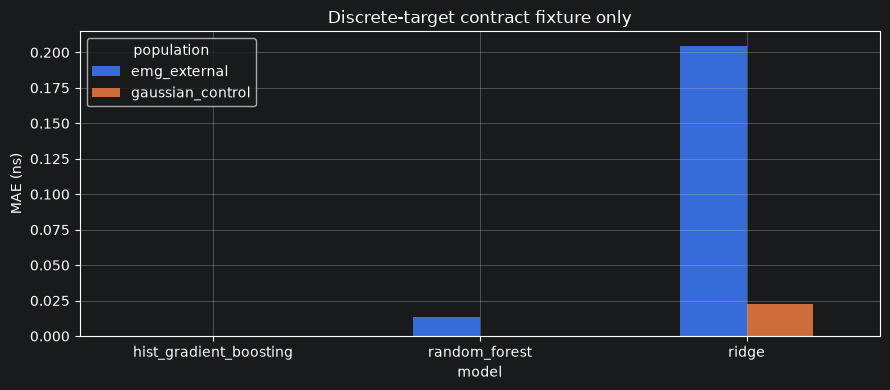

In [12]:
population_rows = []
for label, population in (
    ('gaussian_development', shape_dataset.gaussian_development),
    ('gaussian_control', shape_dataset.gaussian_control),
    ('emg_external', shape_dataset.emg_external),
):
    values, counts = np.unique(population.y, return_counts=True)
    population_rows.append({
        'population': label, 'n_histograms': len(population.y),
        'raw_histogram_shape': population.X_histograms.shape,
        'finite_histograms': bool(np.all(np.isfinite(population.X_histograms))),
        'lifetime_ns_to_count': dict(zip(values, counts)),
    })
display(pd.DataFrame(population_rows))
ml_transfer = evaluate_gaussian_trained_irf_transfer(
    shape_dataset, feature_config=feature_config,
    random_state=manifest['ml']['random_state'],
)
assert ml_transfer.n_gaussian_development_samples == 120
print('Model feature columns:', ml_transfer.feature_names)
display(ml_transfer.summary)
ml_transfer.summary.pivot(
    index='model', columns='population', values='mae_ns',
).plot.bar(ylabel='MAE (ns)', rot=0, title='Discrete-target contract fixture only')
plt.tight_layout()
plt.show()

The audited MAEs (Gaussian control → EMG) are about 0.0223 → 0.2046 ns for Ridge, 0 → 0.01375 ns for RF, and 0.000027 → 0.000027 ns for HGB. Mean RF tree spread increases from 0 to about 0.0569 ns.

The near-perfect Gaussian-control RF/HGB performance reflects this tiny high-count, discrete-target, controlled-nuisance fixture: tree leaves can identify already-seen lifetime levels. New Poisson realizations do not make this an unseen-lifetime generalization test. HGB's absence of measurable EMG degradation is a **negative result for this fixture only**, not evidence of general robustness to asymmetric IRFs. No experiment was altered to force degradation.

## 12. Scientific conclusions

1. Matching sampled IRF peak and full FWHM does not remove shape-induced lifetime bias.
2. Model-conditional intervals can remain narrow around biased estimates; they do not establish correct IRF physics.
3. Leading-edge proxies can be useful when lifetime is long relative to the response width and the rise is instrument dominated.
4. Numerical proxy construction does not guarantee physical correctness; an unseen tail, emission rise, or short lifetime cannot generally be diagnosed from one histogram.
5. Some adverse regimes produce flags or construction failure; others remain deceptively valid.

This extends Week 9's distinction between uncertainty *within* an assumed model and evidence that the assumed model is physically correct. No proxy is an independently measured IRF, no missing IRF is estimated automatically, and no new unique mono-exponential truth is assigned to mixed/rising decays.

The tables and plots above come from committed library code and the versioned manifest. Per-realization records remain available in `classical.per_fit`, `classical.pairs`, `conditional.detailed_results`, `ml_transfer.per_prediction`, and `leading_evaluation.cases`; larger sweeps would need their own explicit configuration and interpretation.